# Lab 01 - 1 : Solutions #

## Vectors and matrices ##

**1A**
* Construct a 10x10 matrix `A` of ones 
    * Hint: https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html
* Substitute the value in position (8,8) with 4
* Extract and print out the 3x3 submatrix `B` corresponding to the last three rows and columns of the matrix (lower right)
* Create and print out `B^2` (B @ B)
* Create and print out `B^2` elementwise

In [5]:
import numpy as np

A = np.ones((10,10))
A[8,8] = 4
B = A[-3:, -3:]
C = B @ B
D = B**2
print(C)
print(D)

[[ 3.  6.  3.]
 [ 6. 18.  6.]
 [ 3.  6.  3.]]
[[ 1.  1.  1.]
 [ 1. 16.  1.]
 [ 1.  1.  1.]]


**1B**
* Construct a 3x2 matrix `M` of random numbers 
    * Hint: https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html
* Reduce the matrix using the sum and mean operations over its rows and columns
* Finally, provide the total sum and mean of the matrix (naturally, results will vary based on the random numbers)

In [6]:
M = np.random.rand(3,2)
sum_over_rows, sum_over_cols = M.sum(axis=0), M.sum(axis=1)
mean_over_rows, mean_over_cols = M.sum(axis=0), M.sum(axis=1)
total_sum , total_mean = M.sum(), M.mean()

print(M)
print(f"Total sum: {total_sum}, Sum over rows: {sum_over_rows}, Sum over cols: {sum_over_cols}")
print(f"Total mean: {total_mean}, Mean over rows: {mean_over_rows}, Mean over cols: {mean_over_cols}")

[[0.7703978  0.11337202]
 [0.18249591 0.59489633]
 [0.15641248 0.27302955]]
Total sum: 2.0906040851200363, Sum over rows: [1.10930618 0.9812979 ], Sum over cols: [0.88376982 0.77739223 0.42944203]
Total mean: 0.3484340141866727, Mean over rows: [1.10930618 0.9812979 ], Mean over cols: [0.88376982 0.77739223 0.42944203]


**1C**
* Initialize two vectors `v1` and `v2` with values [0 0] and [1 1]
* Assuming the values of the vectors represent carthesian coordinates (x,y) calculate the Euclidean distance between the two points

The Euclidean distance is:

$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (y_i - x_i)^2}
$$

For:

$x = v_1 = (0,0)$  
$y = v_2 = (1,1)$

$$
d = \sqrt{(1 - 0)^2 + (1 - 0)^2}
$$

$$
d = \sqrt{2} \approx 1.41
$$


In [7]:
v1, v2 = np.array([0, 0]), np.array([1, 1])
dist = np.sqrt(np.sum((v1-v2)**2))

print(dist)

1.4142135623730951


## Conditional instructions and loops ##

**2A**
* Matrices `U` and `V` are given. Each row of `U` and `V` corresponds to a point in 2D Euclidean space
* Construct a distance matrix `D` for which an element `D(i,j)` contains the Euclidean distance between `U(i,:)` and `V(j,:)`

In [9]:
U = np.array([[0, 0],[0, 1],[1, 0]])    # size (3,2)
V = np.array([[-1, -1],[1, 1],[4, 4]])  # size (3,2)

D = np.zeros((U.shape[0],V.shape[0]))   # size (3,3)

for i in range(U.shape[0]):
    for j in range(V.shape[0]):
        D[i,j] = np.sqrt(np.sum((U[i,:]-V[j,:])**2))
        
print(D)

[[1.41421356 1.41421356 5.65685425]
 [2.23606798 1.         5.        ]
 [2.23606798 1.         5.        ]]


**2B**
* Generate a random number with the command `np.random.normal()` (sampled from a standard normal distribution)
    * Hint: https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.normal.html
* Assign to a variable `y` the value 1 if that number is between -1 and 1 (mean +- standard deviation), 0 otherwise (in Python, intersection (AND) is done with the keyword `and`. To do `and` between two numpy vectors: `np.bitwise_and`)
* If I repeat the process 10000 times, how many times does the random number fall in the interval [-1 1]?
* Do the exercise using a loop, and then try to solve the problem without one

In [14]:
x = np.random.normal()
print(x)
y = 1 if x <= 1 and x >= -1 else 0
print(y)

counter = 0
num_samples = 10000
for i in range(num_samples):
    if -1 <= np.random.normal() <= 1:
        counter += 1
print('Number of samples between -1 and 1: ' + str(counter))

# No loops -> greatest advantage of vectorial computation.
x = np.random.normal(size=num_samples) # number of samples to draw
y = np.bitwise_and(x>=-1, x<=1).astype(int)
counter = np.sum(y)
print('Number of samples between -1 and 1: ' + str(counter))

-1.8211841872608663
0
Number of samples between -1 and 1: 6799
Number of samples between -1 and 1: 6814


## Image visualization ##

**3A**
* Upload the image "seattle.png" in Colab, load it and assign it to the variable `I` 
    * Hint: https://pillow.readthedocs.io/en/stable/reference/Image.html
* Extract the numpy array from the loaded image and display it with the imshow command. Print out its shape
* Print out the minimum and maxium values contained in the matrix
    * Hint: https://stackoverflow.com/questions/384759/how-to-convert-a-pil-image-into-a-numpy-array/37675266
* Diplay the loaded image
    * Hint: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.imshow.html

Image array shape: (720, 480)
Max: 255 Min: 0


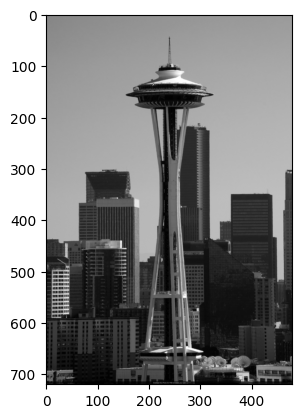

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

I = Image.open('seattle.png')
Inp = np.array(I)
print("Image array shape:", Inp.shape)
print("Max:", np.max(Inp), "Min:", np.min(Inp))

plt.imshow(Inp, cmap='gray')
plt.show()

**3B**
* Using the numpy array from above and the information you printed, try to understand what each element in  the matrix represents. Use that information to perform an "invertion filter" on the image, meaning that  you "switch" the black and white colors
    * Hint: Since the image is in black and white (grayscale), this translatates to simply switchting the gray level of each pixel based on a maximum value
* Print out the means of the normal image and the inverted image

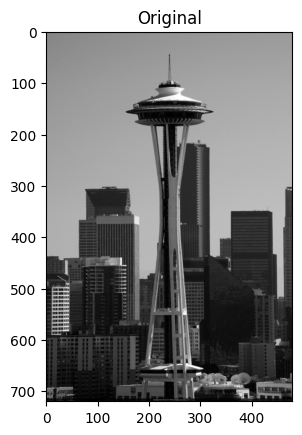

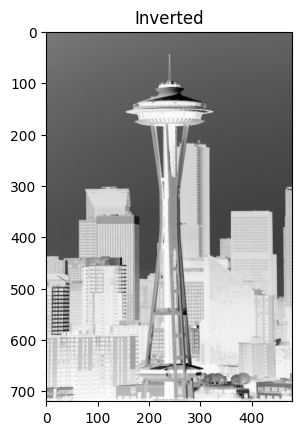

Original mean: 105.54706886574074 Inverted mean: 149.45293113425927
Original mean: 105.54706886574074, Inverted mean: 149.45293113425927


In [4]:
Inv = 255-Inp
plt.imshow(Inp, cmap='gray')
plt.title('Original')
plt.show()
plt.imshow(Inv, cmap='gray')
plt.title('Inverted')
plt.show()

mean_Inp = np.mean(Inp)
mean_Inv = np.mean(Inv)
print('Original mean:', mean_Inp, 'Inverted mean:', mean_Inv)
print(f"Original mean: {mean_Inp}, Inverted mean: {mean_Inv}")